### 工作進度  
* 新的筆記架構仍待定。構想如下：  
  - 第一部分：大盤解盤  
    * 『加權指數』與『櫃買指數』。  
      - 執行mysys.StockAnalysis類別的analysis方法  
        * 針對量化與ＡＩ分析結果加入個人觀點。  
        * 補充老師盤中資訊，來源於[日報](https://mega.nz/folder/a85wHKwK#SA6HACStdXRvMsLd2Ct0tQ) - 這部分在正式上線後會逐日遞減，有興趣者請訂閱 [K線追擊週報](https://smart.businessweekly.com.tw/e-subscription/project?c=GROUP00014146&p=PROD000019311)。
      - 手繪的趨勢線進行量化，使用mysys.DrawOnKlineChart函式。  
  - 第二部分：個股解盤  
    * **選股**來源  
      - 老師觀察股  
        * [K線追擊週報](https://smart.businessweekly.com.tw/e-subscription/project?c=GROUP00014146&p=PROD000019311)LINE群組。  
      - 自選觀察股  
        * [股票篩選器：中價位且平均趨向指標(ADX)上升穿越20](https://tw.tradingview.com/screener/FFH7FtPz/) 。  
    * 個股解盤  
      - 執行mysys.StockAnalysis類別的analysis方法。
      - 將手繪的趨勢線進行量化，使用mysys.DrawOnKlineChart函式。  
      - 補充籌碼面資訊：因為不是所有市場都有籌碼面資訊，因此很難透過AI進行分析，只能人工進行確認。
* 預計8月1日開始使用新的筆記架構，並重啟新的GitHub倉庫來做發佈。  

#### 引入模組與定義公用函式  
* 這部分在筆記架構中該如何定位？  

In [1]:
import numpy as np
import mysys
import markdown
import base64
from IPython.core.display import HTML

In [2]:
def stock_analysis( analysis, stock_id, buttom_pattern = False) :
    results,images = analysis.analysis(stock_id)
    if buttom_pattern is True and '底部型態' in images :
        print('底型反轉交易策略：')
        display(images['底部型態'])
    print('解盤內容：')
    if '整體評價' in images :
        display(images['整體評價'])
    result_md   = results.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

#### 建立「解盤」物件    
* 這部分在筆記架構中該如何定位？  

In [3]:
analysis = mysys.StockAnalysis()

### 大盤解盤  

* 加權指數  

解盤內容：


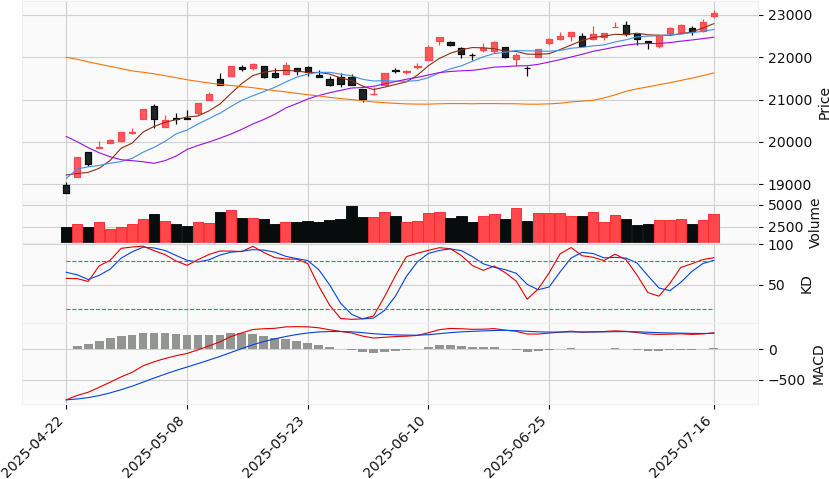

技術分析工具,解盤內容
Ｋ線／Ｋ棒,孕育線／懷抱線 : 2025-07-14
Ｋ線圖,中期為高位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 3912.95億元 ，十日均量 ＝ 3247.32億元）
型態,反轉型態之三重頂，型態範圍由2024-08-12開始到2025-03-03結束，估算目標價為21371.25。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為22257.56。
移動平均線,5日線上揚、10日線上揚，短期翻多；20日線上揚、60日線上揚，中期翻多；120日線上揚、240日線下彎，長期盤整
ＫＤ指標,於2025-07-10黃金交叉。並且2025-07-16於超買區。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-23當周黃金交叉。並且2025-07-07該周在超買區。
整體評價,根據圖表分析如下： 價格趨勢 近期價格呈現上漲趨勢，K線多為紅K，顯示多頭力量較強。短期移動平均線（5日、10日）均向上，且位於中期移動平均線（20日、60日）之上，顯示短期趨勢強勁。 價量關係 成交量在上漲時有所增加，顯示價量配合良好，支持上漲趨勢。這表明市場對於目前的價格上漲有較高的認同度。 支撐與壓力 支撐位可參考20日移動平均線附近，約在22000點左右。壓力位則在近期高點附近，約在23000點。 KD指標解讀 KD指標顯示K線已進入超買區（>80），需留意可能的回檔風險。然而，K線仍高於D線，顯示短期內多頭仍占優勢。 MACD指標解讀 MACD指標中，DIF線高於MACD線，且灰色柱體（OSC）為正，顯示多頭趨勢持續。這進一步支持價格的上漲趨勢。 綜合評價 整體來看，市場目前處於多頭趨勢，短期內可能繼續上漲。然而，由於KD指標進入超買區，需警惕短期回檔風險。建議投資者可考慮在支撐位附近進行佈局，並設置適當的停損點以控制風險。


In [4]:
stock_analysis(analysis,'TAIEX')

In [5]:
def line_drawing_callback( range_prices) :
    # 設定楔形壓力線
    resistance_line_start_date  = '2025-05-14'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_x           = [mysys.DateToIndex(range_prices,'2025-05-16'),mysys.DateToIndex(range_prices,'2025-07-04')]
    resistance_line_y           = [range_prices.loc['2025-05-16']['Close'],range_prices.loc['2025-07-04']['Open']]
    slope,intercept             = np.polyfit(resistance_line_x,resistance_line_y,1)
    resistance_line_start_price = slope * mysys.DateToIndex(range_prices,resistance_line_start_date) + intercept
    resistance_line_end_price   = slope * mysys.DateToIndex(range_prices,resistance_line_end_date) + intercept

    # 設定楔形支撐線
    support_line_start_date  = '2025-06-02'
    support_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    support_line_x           = [mysys.DateToIndex(range_prices,'2025-06-02'),mysys.DateToIndex(range_prices,'2025-07-09')]
    support_line_y           = [range_prices.loc['2025-06-02']['Low'],(range_prices.loc['2025-07-08']['Close'] + range_prices.loc['2025-07-09']['Open'])/2]
    slope,intercept          = np.polyfit(support_line_x,support_line_y,1)
    support_line_start_price = slope * mysys.DateToIndex(range_prices,support_line_start_date) + intercept
    support_line_end_price   = slope * mysys.DateToIndex(range_prices,support_line_end_date) + intercept

    seq_of_seq_of_points=[
        [(resistance_line_start_date,resistance_line_start_price),(resistance_line_end_date,resistance_line_end_price)],
        [(support_line_start_date,support_line_start_price),(support_line_end_date,support_line_end_price)]
    ]

    linewidths=[1.5,1.5]
    
    colors=['xkcd:red','xkcd:red']

    return seq_of_seq_of_points,linewidths,colors

In [6]:
image = mysys.DrawOnKlineChart('TAIEX','2025-03-19','2025-07-16',line_drawing_callback)

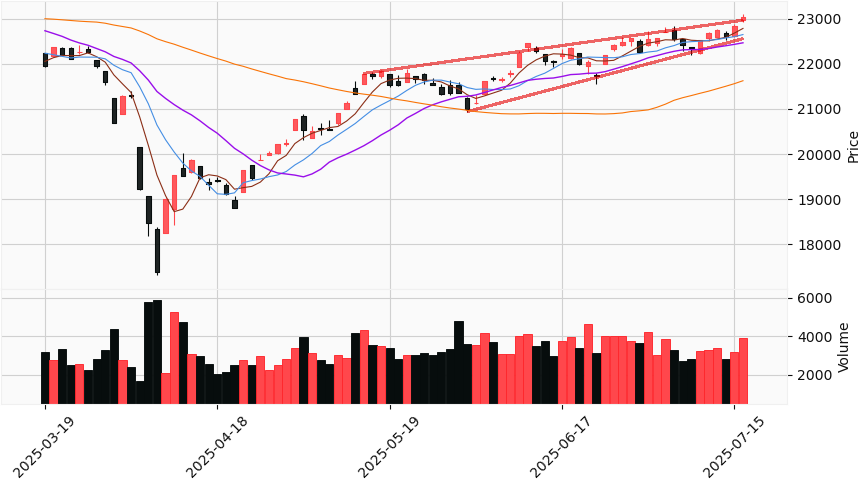

In [7]:
display(image)

* 櫃買指數  

解盤內容：


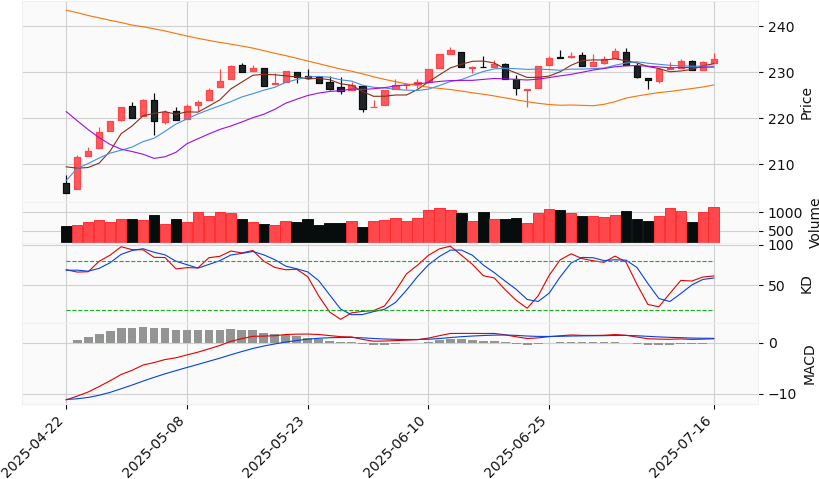

技術分析工具,解盤內容
Ｋ線／Ｋ棒,
Ｋ線圖,中期為中位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 1157.43億元 ，十日均量 ＝ 952.81億元）
型態,盤整型態之三角形，型態範圍由2024-07-11開始到2025-03-28結束。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為247.79。
移動平均線,5日線上揚、10日線下彎，短期盤整；20日線上揚、60日線上揚，中期翻多；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-10黃金交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-02當周死亡交叉。
整體評價,價格趨勢分析 從圖中可以看到，近期價格呈現盤整狀態。K線在230至240點之間波動，顯示出市場缺乏明顯的方向性。短期移動平均線（5日和10日）與中期移動平均線（20日和60日）交錯，進一步支持盤整的判斷。 價量關係 成交量在盤整期間並未出現明顯的放大或縮小，顯示出市場參與者的觀望情緒。價量配合不明顯，無法確認多頭或空頭的明顯優勢。 支撐與壓力判斷 支撐位置大約在230點，壓力位置則在240點。價格多次在這兩個位置之間反彈或回檔，顯示出這些位置的有效性。 KD指標解讀 KD指標顯示K線和D線在50以上，並且K線略高於D線，顯示出短期內有些許的上漲動能，但尚未進入超買區，市場可能會繼續盤整。 MACD指標解讀 MACD指標中，DIF線和MACD線接近零軸，且柱狀體顯示出動能較弱，這與盤整的價格走勢一致。沒有明顯的多空信號。 綜合評價 綜合以上分析，目前市場處於盤整狀態，短期內缺乏明顯的趨勢方向。建議投資者保持觀望，等待價格突破支撐或壓力位置後再行操作。若價格突破240點，可能會有進一步上漲的空間；若跌破230點，則需警惕下行風險。


In [8]:
stock_analysis(analysis,'TPEx')

In [9]:
def line_drawing_callback( range_prices) :
    # 設定箱型壓力線
    resistance_line_start_date  = '2025-06-09'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_price       = range_prices.loc['2025-07-03']['Close']

    # 設定箱型支撐線
    support_line_start_date  = '2025-06-03'
    support_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    support_line_price       = range_prices.loc['2025-06-24']['Open']

    seq_of_seq_of_points=[
        [(resistance_line_start_date,resistance_line_price),(resistance_line_end_date,resistance_line_price)],
        [(support_line_start_date,support_line_price),(support_line_end_date,support_line_price)]
    ]

    linewidths=[5.0,6.0]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow']

    return seq_of_seq_of_points,linewidths,colors

In [10]:
image = mysys.DrawOnKlineChart('TPEx','2025-05-28','2025-07-16',line_drawing_callback)

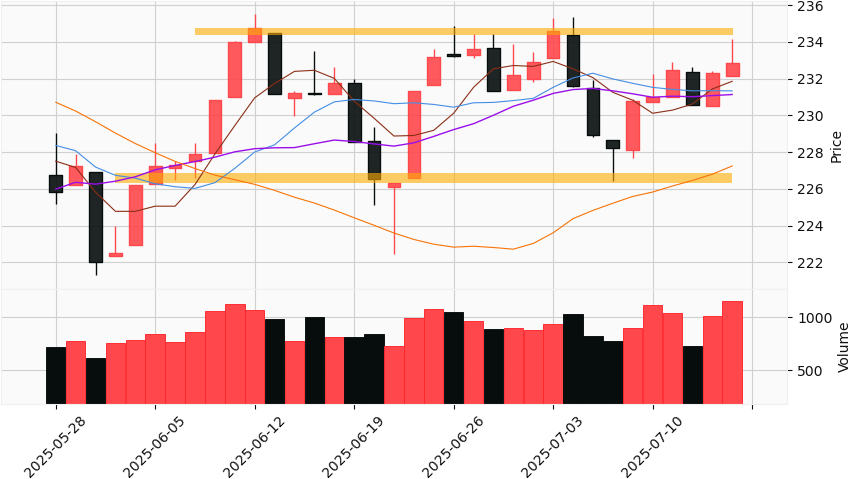

In [11]:
display(image)